# PopOut — Decision Tree AI Pipeline

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — find the minimum number of features needed to play well
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each worker plays one **complete game** and records every position as a
`(board state, best move)` training pair.

**Oracle** (`ReuseFlatNumbaSolverMCTS` at 100 k iter): plays one fixed side and
labels every position — including the opponent's turns. Reuse is enabled between
the oracle's consecutive turns, so later positions inherit the prior search tree
and effectively get more than 100 k iterations, discovering more proven positions.

**Opponent labels** (`FlatNumbaSolverMCTS`, fresh each call): used to label
positions on the opponent's turns. Fresh search is correct here because the
opponent may have blundered to reach the position via a path the oracle never explored.

**Opening diversity**: the opponent's first 2 moves are forced, cycling through
all 49 column combinations (7×7) so every opening is covered across all tiers.

**Blunder tiers**: three equal groups with 5 %, 25 %, and 50 % blunder rate —
covering near-optimal, medium, and weak opponent play in equal measure.

**Checkpointing**: progress is saved to disk every 500 games.  If the run is
interrupted, re-running this cell automatically resumes from the last checkpoint.

In [ ]:
N_GAMES          = 75_000
ORACLE_ITERS     = 100_000
CHECKPOINT_EVERY = 500
VERSION          = 'v4_75k_100k'

DATA_PATH     = Path(f'../data/generated/{VERSION}/popout_dt_dataset.csv')
PROGRESS_PATH = DATA_PATH.with_suffix('.progress')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

BLUNDER_TIERS = [(1/3, 0.05), (1/3, 0.25), (1/3, 0.50)]

if DATA_PATH.exists() and not PROGRESS_PATH.exists():
    # Completed run — just load
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df):,} rows <- {DATA_PATH}')
    print('Delete the file and re-run to regenerate.')
else:
    games_done = int(PROGRESS_PATH.read_text()) if PROGRESS_PATH.exists() else 0

    if games_done > 0:
        print(f'Resuming: {games_done:,}/{N_GAMES:,} games already done')
    else:
        print(f'Starting fresh: {N_GAMES:,} games | oracle={ORACLE_ITERS:,} iter/move | workers={os.cpu_count()}')

    t_run = time.perf_counter()

    for batch_start in range(games_done, N_GAMES, CHECKPOINT_EVERY):
        batch_end = min(batch_start + CHECKPOINT_EVERY, N_GAMES)

        print(f'  Games {batch_start+1:>5}–{batch_end:<5} / {N_GAMES:,} ...', end='  ', flush=True)
        t0 = time.perf_counter()

        batch_df = generate_dataset_parallel(
            n_games=batch_end - batch_start,
            oracle_iterations=ORACLE_ITERS,
            blunder_tiers=BLUNDER_TIERS,
            seed=42 + batch_start,
        )

        # Append to the final CSV — header only on the very first write
        batch_df.to_csv(DATA_PATH, mode='a', header=not DATA_PATH.exists(), index=False)
        # Update progress counter — resume reads this to skip ahead
        PROGRESS_PATH.write_text(str(batch_end))

        print(f'{len(batch_df):>7,} rows | {time.perf_counter()-t0:>6.0f} s | {batch_end:,}/{N_GAMES:,} games done')

    df = pd.read_csv(DATA_PATH)
    PROGRESS_PATH.unlink()  # absence of this file signals a clean completed run

    print(f'\nDone in {(time.perf_counter()-t_run)/3600:.2f} h  |  {len(df):,} rows  |  {len(df)/N_GAMES:.1f} rows/game')
    print(f'Saved -> {DATA_PATH}')

print(f'\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

## 2. Data Exploration

In [3]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 75830 / 193058 (39.3%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,2,0,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,drop_4,0


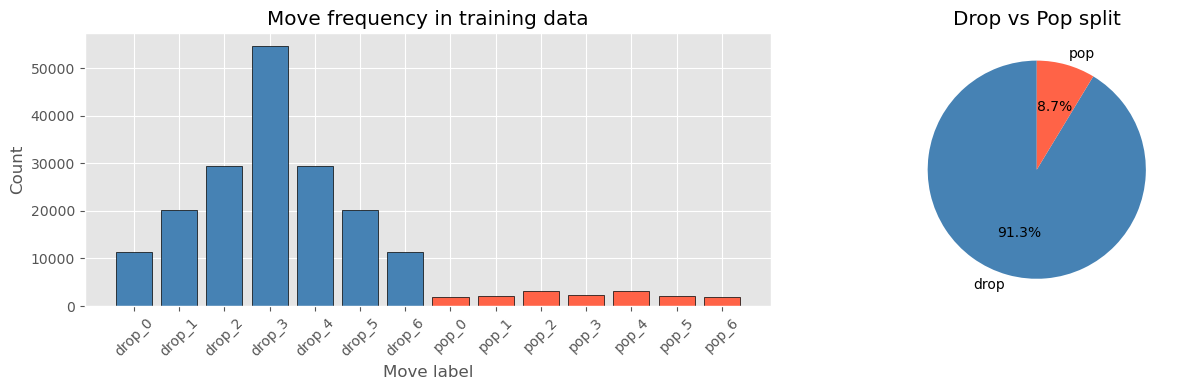

Drop moves: 176330 (91.3%)   Pop moves: 16728 (8.7%)


In [4]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

In [ ]:
OVERSAMPLE_FACTOR = 4   # proven positions are duplicated this many extra times

# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# Filter out positions where the agent can win immediately: _forced_move handles
# these before consulting the tree, so the tree is never called for them during
# play. Including them in training would teach the tree a rule it never applies.
# can_win=1 positions are kept in the CSV for future use without _forced_move.
df_str_train = df_str[df_str['can_win'].astype(str) != '1'].reset_index(drop=True)
print(f'Filtered out {len(df_str) - len(df_str_train):,} can_win=1 positions '
      f'({(len(df_str) - len(df_str_train))/len(df_str):.1%} of dataset)')

# 80 / 20 split
df_train = df_str_train.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df_str_train.drop(df_train.index).reset_index(drop=True)

if 'is_proven' in df_train.columns:
    proven = df_train[df_train['is_proven'].astype(str) == '1']
    df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR,
                             ignore_index=True)
    print(f'Proven rows: {len(proven)} ({len(proven)/len(df_train):.1%} of train)')
    print(f'After oversampling: {len(df_train_aug)} rows  '
          f'(proven share: {(len(proven)*(1+OVERSAMPLE_FACTOR))/len(df_train_aug):.1%})')
else:
    df_train_aug = df_train
    print('No is_proven column — skipping oversampling (regenerate dataset to enable).')

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

clf_full = ID3Classifier(max_depth=15)
t0 = time.perf_counter()
clf_full.fit(df_train_aug[FEATURE_COLS + [TARGET]], target=TARGET)
train_time = time.perf_counter() - t0

train_acc = clf_full.score(df_train[FEATURE_COLS + [TARGET]], target=TARGET)
test_acc  = clf_full.score(df_test[FEATURE_COLS  + [TARGET]], target=TARGET)

print(f'Training time : {train_time:.2f} s')
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

preds   = clf_full.predict(df_test[FEATURE_COLS])
correct = (preds == df_test[TARGET].astype(str))
print(f'\nTactical accuracy:')
for feat, val in [('opp_wins_next', '1')]:
    if feat in df_test.columns:
        mask = df_test[feat].astype(str) == val
        if mask.sum() > 0:
            print(f'  {feat}=1  (n={mask.sum():4d}): {correct[mask].mean():.3f}')
pop_mask = df_test[TARGET].str.startswith('pop')
if pop_mask.sum() > 0:
    print(f'  pop moves  (n={pop_mask.sum():4d}): {correct[pop_mask].mean():.3f}')

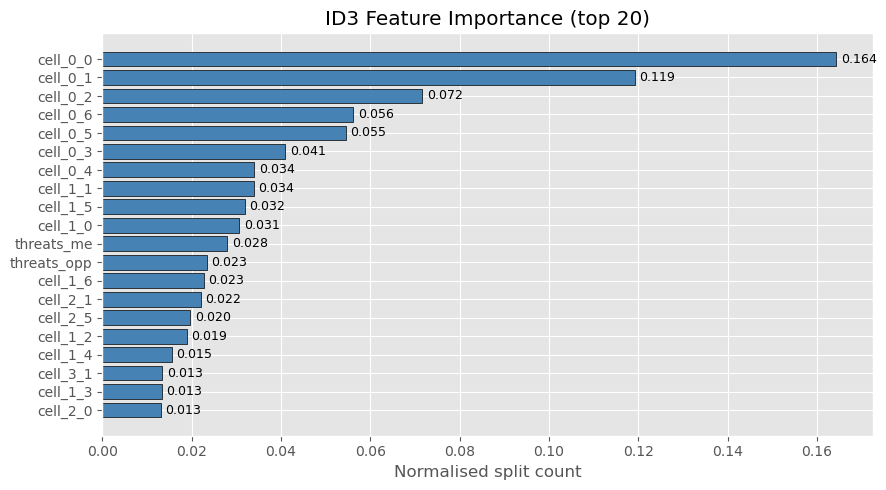

In [6]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the training set, then train
separate ID3 trees using only the top-K features.  The accuracy curve reveals the
**minimum feature budget** the game requires to achieve good move prediction.

In [7]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. center_me           IG = 0.3871
   2. center_opp          IG = 0.3512
   3. phase               IG = 0.3111
   4. cell_2_3            IG = 0.2568
   5. cell_3_3            IG = 0.2229
   6. cell_1_3            IG = 0.1895
   7. threats_opp         IG = 0.1698
   8. cell_4_3            IG = 0.1671
   9. cell_1_4            IG = 0.1337
  10. cell_1_2            IG = 0.1327


In [8]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.354  test=0.363
K=  3  train=0.379  test=0.381
K=  5  train=0.412  test=0.407
K= 10  train=0.593  test=0.563
K= 15  train=0.770  test=0.745
K= 20  train=0.823  test=0.797
K= 30  train=0.887  test=0.858
K= 50  train=0.911  test=0.878


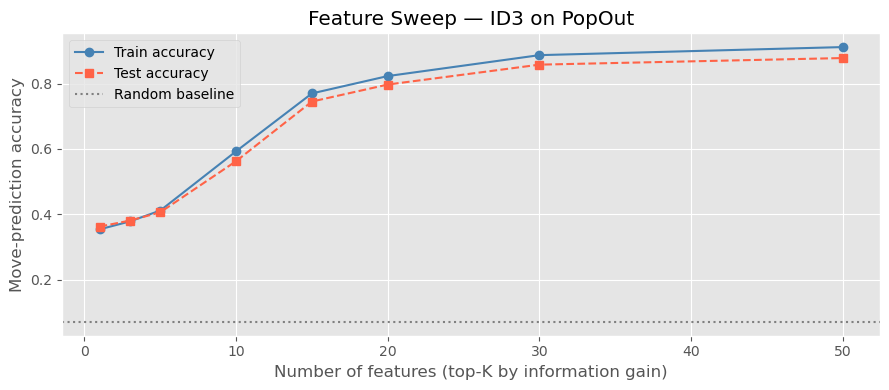

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Win-Rate Evaluation

The ID3 tree is evaluated against two engine families at multiple iteration counts:

| Engine | Iterations tested | Notes |
|---|---|---|
| **FlatNumbaMCTS** | 100 · 500 · 1 000 · 5 000 · 10 000 | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | 1 000 · 5 000 · 10 000 · 50 000 · 100 000 | MCTS-Solver, exits when proven & all root moves tried |

100 games per configuration, alternating sides for balance.
Moves are selected through the full `ID3Agent`/`ID3AgentRaw` wrappers,
which include the `_forced_move` rule layer (immediate win / block) before
consulting the tree.

In [ ]:
import pickle, gc

PICKLE_PATH     = Path(f'../data/generated/{VERSION}/id3_model.pkl')
PICKLE_RAW_PATH = Path(f'../data/generated/{VERSION}/id3_model_raw.pkl')

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
RAW_OVERSAMPLE = 10
RAW_DEPTH      = 20

def _filter_can_win(df):
    """Drop positions where can_win=1 — _forced_move handles those during play."""
    if 'can_win' not in df.columns:
        return df
    return df[df['can_win'] != 1].reset_index(drop=True)

# ── ID3 with engineered features ─────────────────────────────────────────────
if PICKLE_PATH.exists():
    print(f'Loading clf_game from {PICKLE_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_PATH, 'rb') as f:
        clf_game = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print('Training clf_game on full dataset (features, depth=15, 4x proven oversampling)...')
    _df = _filter_can_win(df.copy())
    print(f'  After can_win=1 filter: {len(_df):,} rows')
    _feat_cols = [c for c in _df.columns if c not in ('best_move', 'is_proven')]
    if 'is_proven' in _df.columns:
        _proven = _df[_df['is_proven'] == 1]
        _df = pd.concat([_df] + [_proven] * 4, ignore_index=True)
        del _proven
    for c in _feat_cols: _df[c] = _df[c].astype(str)
    _df['best_move'] = _df['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game = ID3Classifier(max_depth=15)
    clf_game.fit(_df[_feat_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df; gc.collect()
    PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f: pickle.dump(clf_game, f)
    print(f'  Saved to {PICKLE_PATH}')

# ── ID3 Raw (raw cells only, heavy proven oversampling) ───────────────────────
if PICKLE_RAW_PATH.exists():
    print(f'\nLoading clf_game_raw from {PICKLE_RAW_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_RAW_PATH, 'rb') as f:
        clf_game_raw = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'\nTraining clf_game_raw (raw cells, depth={RAW_DEPTH}, {RAW_OVERSAMPLE}x proven)...')
    _df_raw = _filter_can_win(df.copy())
    print(f'  After can_win=1 filter: {len(_df_raw):,} rows')
    _raw_cols = [c for c in _df_raw.columns if c not in _EXCLUDE_RAW]
    if 'is_proven' in _df_raw.columns:
        _proven = _df_raw[_df_raw['is_proven'] == 1]
        _df_raw = pd.concat([_df_raw] + [_proven] * RAW_OVERSAMPLE, ignore_index=True)
        del _proven
    for c in _raw_cols: _df_raw[c] = _df_raw[c].astype(str)
    _df_raw['best_move'] = _df_raw['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game_raw = ID3Classifier(max_depth=RAW_DEPTH)
    clf_game_raw.fit(_df_raw[_raw_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df_raw; gc.collect()
    PICKLE_RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_RAW_PATH, 'wb') as f: pickle.dump(clf_game_raw, f)
    print(f'  Saved to {PICKLE_RAW_PATH}')

In [3]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.3 s


In [4]:
from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

def _make_tree_agent(clf, raw=False):
    """Wrap an already-trained classifier in the agent class (includes _forced_move)."""
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf
    return agent

def play_one_game(tree_agent, mcts_agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game. Returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        if mover == tree_plays_as:
            move = tree_agent.run(board)
        else:
            move = mcts_agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [5]:
EVAL_GAMES = 100

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

TREE_MODELS = {
    'ID3 (features)': _make_tree_agent(clf_game,     raw=False),
    'ID3 Raw':        _make_tree_agent(clf_game_raw, raw=True),
}

eval_results = {}

t0 = time.perf_counter()
for model_name, tree_agent in TREE_MODELS.items():
    print(f'\n── {model_name} ──')
    for engine_name, iter_list in CONFIGS.items():
        for iters in iter_list:
            mcts_agent = (FlatNumbaMCTS(max_nodes=iters + 256)
                          if engine_name == 'FlatNumbaMCTS'
                          else FlatNumbaSolverMCTS(max_nodes=iters + 256))
            wins = losses = draws = 0
            for i in range(EVAL_GAMES):
                r = play_one_game(tree_agent, mcts_agent, 1 if i % 2 == 0 else 2, iters)
                if r == 1:    wins   += 1
                elif r == -1: losses += 1
                else:         draws  += 1
            eval_results[(model_name, engine_name, iters)] = (wins, losses, draws)
            wr = wins / EVAL_GAMES
            print(f'  {engine_name:22s}  {iters:7,d} iter  ->  {wr:5.1%}  '
                  f'({wins}W / {losses}L / {draws}D)')
        print()

print(f'Total evaluation time: {time.perf_counter() - t0:.1f} s')


── ID3 (features) ──
  FlatNumbaMCTS               100 iter  ->  89.0%  (89W / 11L / 0D)
  FlatNumbaMCTS               500 iter  ->  69.0%  (69W / 31L / 0D)
  FlatNumbaMCTS             1,000 iter  ->  50.0%  (50W / 50L / 0D)
  FlatNumbaMCTS             5,000 iter  ->  37.0%  (37W / 63L / 0D)
  FlatNumbaMCTS            10,000 iter  ->  27.0%  (27W / 73L / 0D)

  FlatNumbaSolverMCTS       1,000 iter  ->  46.0%  (46W / 54L / 0D)
  FlatNumbaSolverMCTS       5,000 iter  ->  32.0%  (32W / 68L / 0D)
  FlatNumbaSolverMCTS      10,000 iter  ->  35.0%  (35W / 65L / 0D)
  FlatNumbaSolverMCTS      50,000 iter  ->  54.0%  (54W / 46L / 0D)
  FlatNumbaSolverMCTS     100,000 iter  ->  51.0%  (51W / 49L / 0D)


── ID3 Raw ──
  FlatNumbaMCTS               100 iter  ->  94.0%  (94W / 6L / 0D)
  FlatNumbaMCTS               500 iter  ->  66.0%  (66W / 33L / 1D)
  FlatNumbaMCTS             1,000 iter  ->  62.0%  (62W / 38L / 0D)
  FlatNumbaMCTS             5,000 iter  ->  51.0%  (51W / 49L / 0D)
  FlatNumb

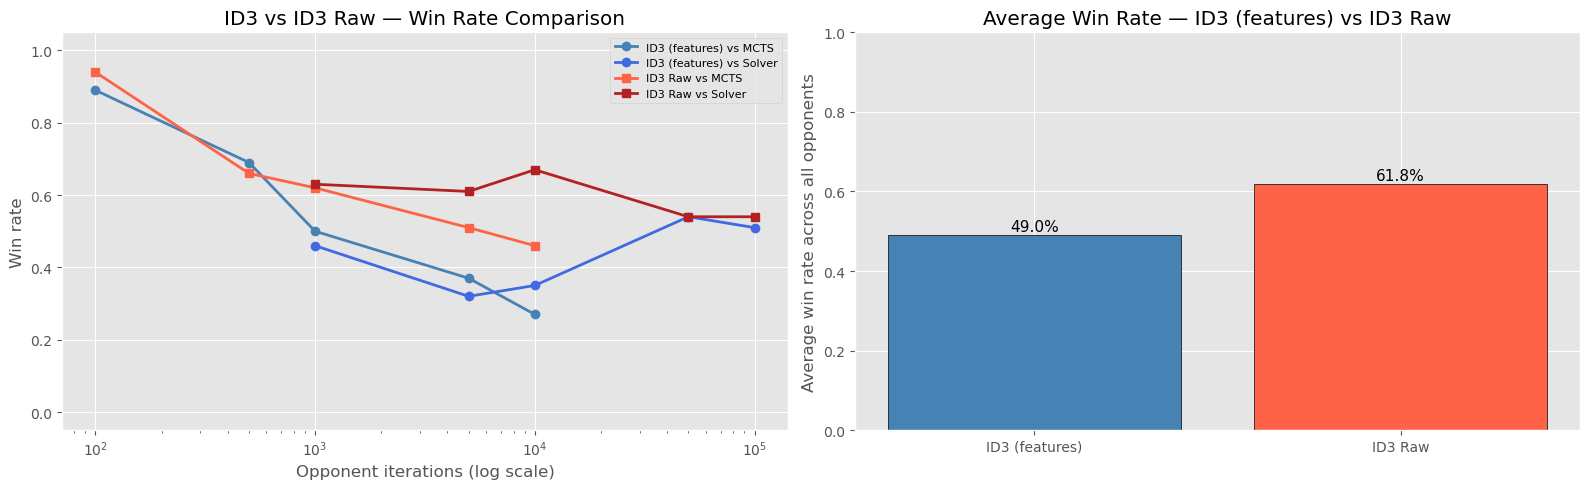


Model                 Opponent engine         Iterations     Win%     W     L     D
---------------------------------------------------------------------------
ID3 (features)        FlatNumbaMCTS                  100    89.0%    89    11     0
ID3 (features)        FlatNumbaMCTS                  500    69.0%    69    31     0
ID3 (features)        FlatNumbaMCTS                1,000    50.0%    50    50     0
ID3 (features)        FlatNumbaMCTS                5,000    37.0%    37    63     0
ID3 (features)        FlatNumbaMCTS               10,000    27.0%    27    73     0
ID3 (features)        FlatNumbaSolverMCTS          1,000    46.0%    46    54     0
ID3 (features)        FlatNumbaSolverMCTS          5,000    32.0%    32    68     0
ID3 (features)        FlatNumbaSolverMCTS         10,000    35.0%    35    65     0
ID3 (features)        FlatNumbaSolverMCTS         50,000    54.0%    54    46     0
ID3 (features)        FlatNumbaSolverMCTS        100,000    51.0%    51    49     0

In [6]:
ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}
MODEL_COLORS = {'ID3 (features)': {'FlatNumbaMCTS': 'steelblue', 'FlatNumbaSolverMCTS': 'royalblue'},
                'ID3 Raw':        {'FlatNumbaMCTS': 'tomato',    'FlatNumbaSolverMCTS': 'firebrick'}}
MODEL_MARKERS = {'ID3 (features)': 'o', 'ID3 Raw': 's'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        win_rates = [eval_results[(model_name, engine_name, it)][0] / EVAL_GAMES
                     for it in iter_list]
        axes[0].plot(iter_list, win_rates,
                     marker=MODEL_MARKERS[model_name], linestyle='-',
                     color=MODEL_COLORS[model_name][engine_name], linewidth=2,
                     label=f'{model_name} vs {ENGINE_SHORT[engine_name]}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('Win rate')
axes[0].set_title('ID3 vs ID3 Raw — Win Rate Comparison')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=8)

model_names = list(TREE_MODELS.keys())
avg_wr = [
    np.mean([eval_results[(m, eng, it)][0] / EVAL_GAMES
             for eng, iters in CONFIGS.items() for it in iters])
    for m in model_names
]
bar_colors = ['steelblue', 'tomato']
axes[1].bar(model_names, avg_wr, color=bar_colors, edgecolor='black')
for i, v in enumerate(avg_wr):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)
axes[1].set_ylabel('Average win rate across all opponents')
axes[1].set_title('Average Win Rate — ID3 (features) vs ID3 Raw')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f'\n{"Model":<20}  {"Opponent engine":<22}  {"Iterations":>10}  {"Win%":>7}  {"W":>4}  {"L":>4}  {"D":>4}')
print('-' * 75)
for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        for it in iter_list:
            w, l, d = eval_results[(model_name, engine_name, it)]
            print(f'{model_name:<20}  {engine_name:<22}  {it:>10,}  '
                  f'{w/EVAL_GAMES:>7.1%}  {w:>4}  {l:>4}  {d:>4}')
    print()